<h2>Import requirements

In [21]:
import pandas as pd
import numpy as np
from keras.models import load_model
from sklearn.inspection import permutation_importance
import shap
import matplotlib.pyplot as plt
seed = 0; np.random.seed(seed)

<h2>>> Regular model

<h4>Load test data

In [28]:
DATA = np.loadtxt('data/my_lol_dataset.csv', delimiter=',', skiprows=1)
X = DATA[:, :-1]
y = DATA[:, -1]

<h4>Load model

In [29]:
model = load_model('models/lol_model.keras')

<h4>Evaluate model

In [30]:
loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"Accuracy on new data: {accuracy}%")

Accuracy on new data: 0.8606557250022888%


<h4>Check feature importance

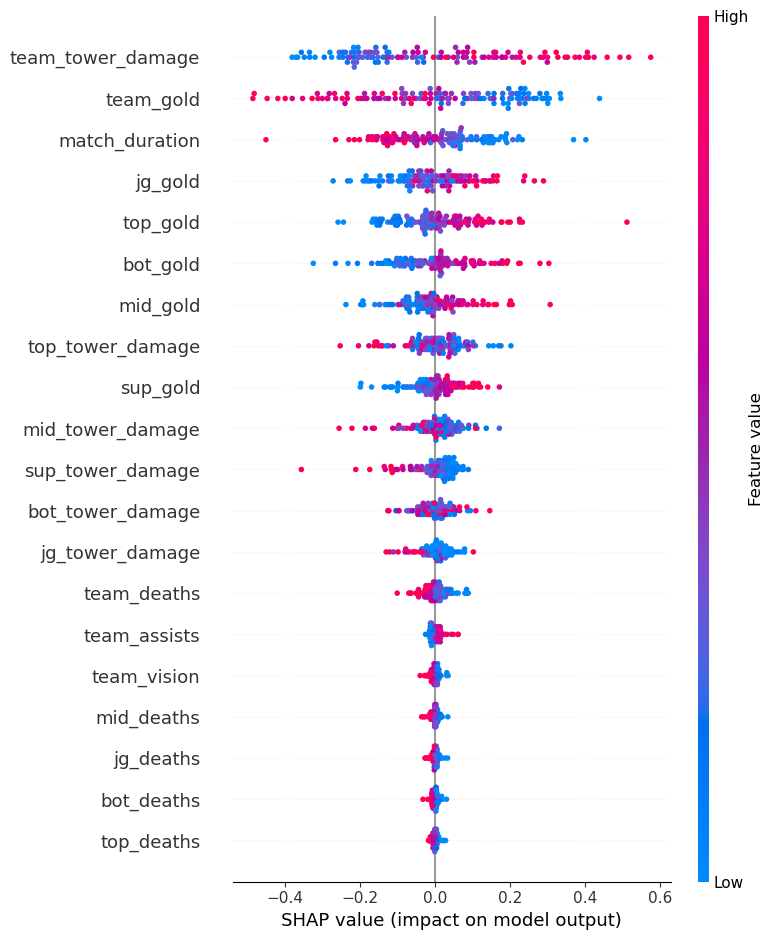

In [31]:
headers = pd.read_csv('data/my_lol_dataset.csv', nrows=0).columns.tolist()
feature_names = headers[:-1]

explainer = shap.Explainer(model, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X, feature_names=feature_names)

<h2>>> Normalized model

<h4>Load test data

In [34]:
DATA_norm = np.loadtxt('data/my_lol_dataset_normalized.csv', delimiter=',', skiprows=1)
X_norm = DATA_norm[:, :-1]
y_norm = DATA_norm[:, -1]

<h4>Load model

In [35]:
normalized_model = model = load_model('models/lol_model_normalized.keras')

<h4>Evaluate model

In [36]:
loss, accuracy = normalized_model.evaluate(X_norm, y_norm, verbose=0)
print(f"Accuracy on new data: {accuracy}%")

Accuracy on new data: 0.8934426307678223%


<h4>Check feature importance

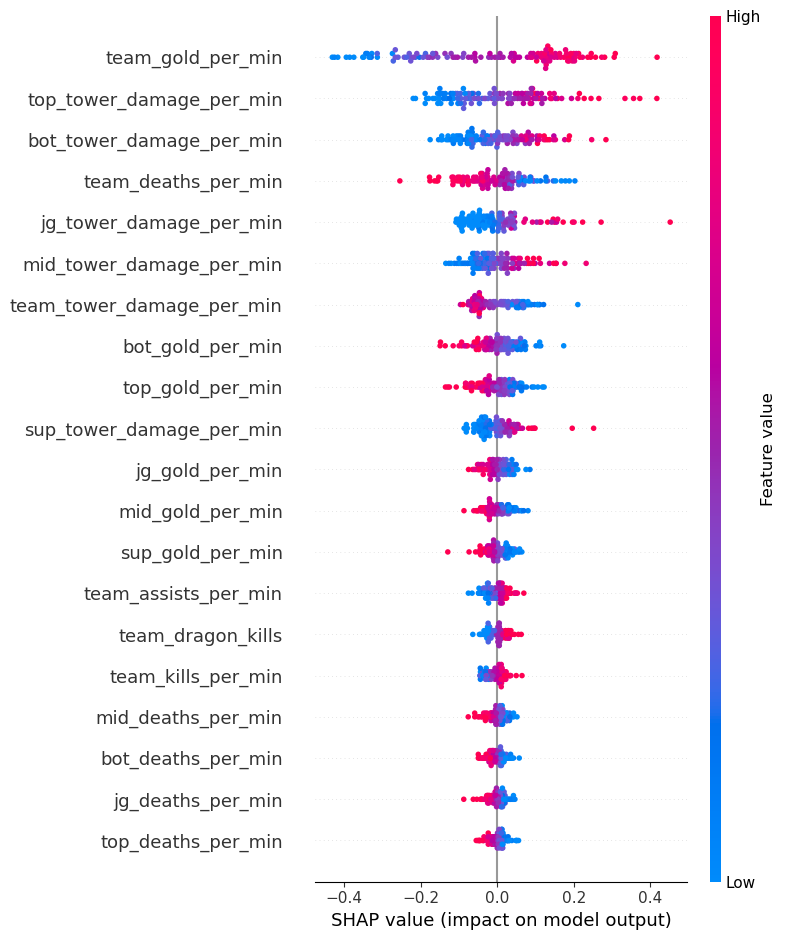

In [39]:
headers = pd.read_csv('data/my_lol_dataset_normalized.csv', nrows=0).columns.tolist()
feature_names = headers[:-1]

explainer_norm = shap.Explainer(normalized_model, X_norm)
shap_values_norm = explainer_norm(X_norm)

shap.summary_plot(shap_values_norm, X_norm, feature_names=feature_names)